
# Customer Churn Prediction – End to End Data Science Case Study

 
**Goal:** Build and evaluate machine learning models to predict customer churn for a subscription business, and extract actionable insights for stakeholders.

This notebook covers:

1. Problem definition and data  
2. Exploratory data analysis (EDA)  
3. Data preprocessing and feature engineering  
4. Model training and evaluation  
5. Feature importance and insights  
6. Business recommendations and next steps  



## 1. Problem definition and data

A subscription-based company (for example telecom, SaaS, or streaming) wants to reduce customer churn.  
Management asks:

- Can we **predict which customers are likely to churn** in the near future?  
- What are the **main drivers** of churn?  
- How can we **target retention actions** more effectively?  

We use a public Telco Customer Churn dataset that contains:

- Customer demographics (gender, senior citizen, etc.)  
- Contract information (contract type, payment method, tenure)  
- Charges (monthly charges, total charges)  
- Target variable `Churn` (Yes/No)  



In [1]:

# 1.1 Import libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

import matplotlib.pyplot as plt
import seaborn as sns

# Make plots a bit nicer
sns.set(style="whitegrid")
pd.set_option("display.max_columns", None)


In [2]:

# 1.2 Load the dataset
#
# Place a file named `telco_churn.csv` in the same folder as this notebook
# or update the path below to where your file is stored.
#
# If you downloaded the Kaggle "Telco Customer Churn" dataset, 
# it will typically be named something like `WA_Fn-UseC_-Telco-Customer-Churn.csv`.
# You can rename it to `telco_churn.csv` for convenience.

data_path = "C:/Users/damil/OneDrive/Documents/Freelance/telco_churn/telco_churn.csv"  # change this if needed

df = pd.read_csv(data_path)

print("Shape of raw data:", df.shape)
df.head()


Shape of raw data: (200, 28)


,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,cardten,voice,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
0,11.0,33.0,7.0,136.0,5.0,5.0,0.0,1.0,1.0,4.40,20.75,0.0,15.25,35.7,42.00,211.45,125.0,1.0,1.0,0.0,1.0,1.0,0.0,1.482,3.033,4.913,4.0,1.0
1,33.0,33.0,12.0,33.0,2.0,0.0,0.0,0.0,0.0,9.45,0.00,0.0,0.00,0.0,288.80,0.00,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.246,3.240,3.497,1.0,1.0
2,23.0,30.0,9.0,30.0,1.0,2.0,0.0,0.0,0.0,6.30,0.00,0.0,0.00,0.0,157.05,0.00,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.841,3.240,3.401,3.0,0.0
3,38.0,35.0,5.0,76.0,2.0,10.0,1.0,1.0,1.0,6.05,45.00,50.1,23.25,64.9,239.55,1873.05,880.0,1.0,1.0,1.0,1.0,1.0,1.0,1.800,3.807,4.331,4.0,0.0
4,7.0,35.0,14.0,80.0,2.0,15.0,0.0,1.0,0.0,7.10,22.00,0.0,23.75,0.0,47.45,166.10,145.0,1.0,0.0,0.0,1.0,1.0,0.0,1.960,3.091,4.382,3.0,0.0


In [3]:

# 1.3 Basic info and data types
#
# This helps us understand which columns are numeric vs categorical,
# and if we have missing values or strange data types.

df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 28 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   tenure    200 non-null    float64
 1   age       200 non-null    float64
 2   address   200 non-null    float64
 3   income    200 non-null    float64
 4   ed        200 non-null    float64
 5   employ    200 non-null    float64
 6   equip     200 non-null    float64
 7   callcard  200 non-null    float64
 8   wireless  200 non-null    float64
 9   longmon   200 non-null    float64
 10  tollmon   200 non-null    float64
 11  equipmon  200 non-null    float64
 12  cardmon   200 non-null    float64
 13  wiremon   200 non-null    float64
 14  longten   200 non-null    float64
 15  tollten   200 non-null    float64
 16  cardten   200 non-null    float64
 17  voice     200 non-null    float64
 18  pager     200 non-null    float64
 19  internet  200 non-null    float64
 20  callwait  200 non-null    float6

In [4]:

# Quick look at basic statistics for numeric columns
df.describe()


,tenure,age,address,income,ed,employ,equip,callcard,wireless,longmon,tollmon,equipmon,cardmon,wiremon,longten,tollten,cardten,voice,pager,internet,callwait,confer,ebill,loglong,logtoll,lninc,custcat,churn
count,200.000000,200.000000,200.000000,200.000000,200.00000,200.00000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.0000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000,200.000000
mean,35.505000,41.165000,11.650000,75.130000,2.82500,10.22500,0.425000,0.705000,0.290000,11.78925,13.240000,15.783250,14.358750,12.2170,577.770750,507.007500,650.663750,0.295000,0.275000,0.440000,0.45500,0.460000,0.440000,2.193285,3.229185,3.951015,2.475000,0.290000
std,21.640971,13.076803,10.158419,128.430468,1.28555,8.95743,0.495584,0.457187,0.454901,9.88725,15.643842,19.557103,14.781269,21.6326,746.608653,820.027858,941.470689,0.457187,0.447635,0.497633,0.49922,0.499648,0.497633,0.731282,0.281019,0.752553,1.079445,0.454901
min,1.000000,19.000000,0.000000,9.000000,1.00000,0.00000,0.000000,0.000000,0.000000,1.10000,0.000000,0.000000,0.000000,0.0000,1.100000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.095000,1.749000,2.197000,1.000000,0.000000
25%,16.750000,31.000000,3.000000,31.000000,2.00000,3.00000,0.000000,0.000000,0.000000,5.53750,0.000000,0.000000,0.000000,0.0000,79.337500,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,1.711750,3.226500,3.434000,2.000000,0.000000
50%,33.500000,40.000000,9.000000,48.000000,3.00000,7.50000,0.000000,1.000000,0.000000,8.25000,0.000000,0.000000,12.500000,0.0000,289.525000,0.000000,342.500000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,2.110000,3.240000,3.871000,2.000000,0.000000
75%,55.250000,51.000000,18.000000,80.000000,4.00000,17.00000,1.000000,1.000000,1.000000,14.30000,24.750000,33.012500,20.750000,23.4625,806.762500,724.162500,921.250000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,2.660000,3.240000,4.382000,3.000000,1.000000
max,72.000000,76.000000,48.000000,1668.000000,5.00000,44.00000,1.000000,1.000000,1.000000,62.30000,68.500000,63.250000,109.250000,109.7000,4333.000000,4938.600000,7515.000000,1.000000,1.000000,1.000000,1.00000,1.000000,1.000000,4.132000,4.227000,7.419000,4.000000,1.000000



## 2. Exploratory data analysis (EDA)

In this section we:

- Look at the distribution of the target `Churn`  
- Explore relationships between churn and key features like tenure and charges  
- Inspect correlations between numeric variables  


Churn counts:
churn
0.0    142
1.0     58
Name: count, dtype: int64

Churn ratio:
churn
0.0    0.71
1.0    0.29
Name: proportion, dtype: float64


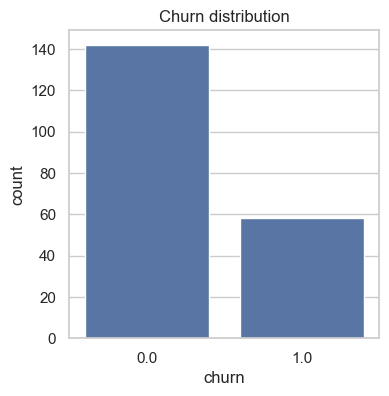

In [7]:

# 2.1 Target distribution
#
# Understanding the class balance is important for model choice and evaluation.

churn_counts = df["churn"].value_counts()
churn_ratio = df["churn"].value_counts(normalize=True)

print("Churn counts:")
print(churn_counts)
print("\nChurn ratio:")
print(churn_ratio)

plt.figure(figsize=(4, 4))
sns.countplot(data=df, x="churn")
plt.title("Churn distribution")
plt.show()


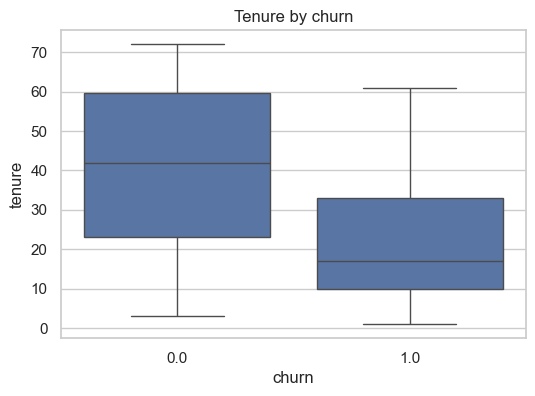

In [9]:

# 2.2 Relationship between churn and tenure
#
# Typical expectation: customers who have been with the company for a very short time
# may be more likely to churn.

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="churn", y="tenure")
plt.title("Tenure by churn")
plt.show()


In [14]:

# 2.3 Relationship between churn and monthly charges
#
# Higher monthly charges may correlate with higher churn if customers feel they pay too much.

plt.figure(figsize=(6, 4))
sns.boxplot(data=df, x="churn", y="monthlycharges")
plt.title("Monthly charges by churn")
plt.show()


ValueError: Could not interpret value `monthlycharges` for `y`. An entry with this name does not appear in `data`.

<Figure size 600x400 with 0 Axes>

In [ ]:

# 2.4 Correlation between numeric features
#
# This gives a quick overview of relationships between numeric variables.

numeric_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(6, 5))
corr = df[numeric_cols].corr()
sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues")
plt.title("Correlation between numeric features")
plt.tight_layout()
plt.show()



### EDA observations (example text you can adapt)

You can adjust this text after you inspect your own plots:

- The dataset is moderately imbalanced, with fewer churned customers than non-churned.  
- Customers with **shorter tenure** tend to churn more often than long-term customers.  
- Customers with **higher monthly charges** show a higher churn rate, which suggests price sensitivity.  
- Numeric correlations are not extreme, but tenure and total charges are reasonably correlated.  



## 3. Data preprocessing and feature engineering

Steps:

1. Handle missing values and clean up data types  
2. Encode the target variable `Churn` as 0/1  
3. Separate features and target  
4. Build preprocessing pipelines:  
   - Standardize numeric features  
   - One hot encode categorical features  
5. Split the data into train and test sets  


In [ ]:

# 3.1 Basic cleaning
#
# Some versions of the Telco dataset have spaces for missing values,
# especially in `TotalCharges`. We replace empty strings with NaN,
# then drop or impute as needed.

# Replace blank strings with NaN
df = df.replace(" ", np.nan)

# Convert TotalCharges to numeric if it is object
if df["TotalCharges"].dtype == "object":
    df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Drop rows with missing TotalCharges for simplicity
df = df.dropna(subset=["TotalCharges"])

print("Shape after cleaning:", df.shape)
df[["tenure", "MonthlyCharges", "TotalCharges"]].head()


In [ ]:

# 3.2 Encode target variable
#
# Map: Yes -> 1 (churn), No -> 0 (stay)

df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

# Confirm that mapping worked
df["Churn"].value_counts()


In [ ]:

# 3.3 Separate features and target
#
# We drop `customerID` because it is an identifier, not a feature.

X = df.drop(columns=["Churn", "customerID"])
y = df["Churn"]

numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X.select_dtypes(exclude=[np.number]).columns.tolist()

print("Numeric features:", numeric_features)
print("Categorical features:", categorical_features)


In [ ]:

# 3.4 Define preprocessing pipelines
#
# - Numeric features: StandardScaler
# - Categorical features: OneHotEncoder

numeric_transformer = Pipeline(
    steps=[("scaler", StandardScaler())]
)

categorical_transformer = Pipeline(
    steps=[("encoder", OneHotEncoder(handle_unknown="ignore"))]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

# 3.5 Train test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    stratify=y,
    random_state=42,
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)



## 4. Model training and evaluation

We train and compare two models:

1. **Logistic Regression** – simple, interpretable baseline  
2. **Random Forest** – non-linear, can capture more complex relationships  

We evaluate using:

- Accuracy  
- Precision, recall, F1-score  
- ROC AUC  
- Confusion matrix  


In [ ]:

# Helper function to evaluate classifiers in a consistent way

def evaluate_model(y_true, y_pred, y_proba, name: str):
    print(f"=== {name} ===")
    print("Accuracy :", round(accuracy_score(y_true, y_pred), 3))
    print("Precision:", round(precision_score(y_true, y_pred), 3))
    print("Recall   :", round(recall_score(y_true, y_pred), 3))
    print("F1-score :", round(f1_score(y_true, y_pred), 3))
    print("ROC AUC  :", round(roc_auc_score(y_true, y_proba), 3))
    print()
    print(classification_report(y_true, y_pred))

    cm = confusion_matrix(y_true, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(f"Confusion matrix – {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.tight_layout()
    plt.show()


In [ ]:

# 4.1 Logistic Regression

log_reg_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000)),
    ]
)

log_reg_clf.fit(X_train, y_train)

y_pred_lr = log_reg_clf.predict(X_test)
y_proba_lr = log_reg_clf.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_lr, y_proba_lr, "Logistic Regression")


In [ ]:

# 4.2 Random Forest

rf_clf = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

rf_clf.fit(X_train, y_train)

y_pred_rf = rf_clf.predict(X_test)
y_proba_rf = rf_clf.predict_proba(X_test)[:, 1]

evaluate_model(y_test, y_pred_rf, y_proba_rf, "Random Forest")



### Model comparison (example commentary)

Adapt this after you see your actual metrics:

- Both models perform reasonably well, but the **Random Forest** often achieves a higher ROC AUC and F1-score than Logistic Regression.  
- The Random Forest may show better recall on the churn class, which is important if we care more about **catching churners** than avoiding false positives.  
- For deployment, we could choose the Random Forest as the primary model and further tune its hyperparameters.  



## 5. Feature importance and insights

Next, we inspect **which features drive churn** according to the Random Forest model.

This helps business stakeholders understand:

- Which customer characteristics are most associated with churn  
- Which levers they can pull for retention campaigns  


In [ ]:

# 5.1 Extract feature names after preprocessing
#
# For the Random Forest, we inspect feature importances.
# We need to reconstruct the feature names from numeric + one hot encoded categorical features.

ohe = rf_clf.named_steps["preprocessor"].named_transformers_["cat"].named_steps["encoder"]
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = np.concatenate([numeric_features, encoded_cat_features])

rf_model = rf_clf.named_steps["model"]
importances = rf_model.feature_importances_

feat_imp = pd.DataFrame(
    {"feature": all_features, "importance": importances}
).sort_values("importance", ascending=False)

feat_imp.head(15)


In [ ]:

# 5.2 Plot top feature importances

top_n = 15
plt.figure(figsize=(8, 6))
sns.barplot(
    data=feat_imp.head(top_n),
    x="importance",
    y="feature",
)
plt.title("Top feature importances for churn prediction (Random Forest)")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()



### Interpreting the feature importances (example text)

Adjust this based on your actual results:

- **Tenure** is one of the strongest predictors of churn – customers with very short tenure are more likely to churn.  
- **MonthlyCharges** and related derived features are also important, indicating that **higher paying customers may be more at risk** if they do not see sufficient value.  
- Certain **contract types** (for example month-to-month) and **payment methods** may have higher churn, suggesting customers on flexible contracts are more likely to leave.  
- Internet service type and add-ons (such as tech support, online security) may also influence churn risk.  



## 6. Business recommendations and next steps

Based on the modeling and analysis, here are example recommendations you can tailor to your results:

### 6.1 Targeted retention strategy

- Use the trained Random Forest model to **score active customers** every month.  
- Flag customers with a **high predicted churn probability** (for example top 20–30%) for proactive outreach.  
- Combine churn scores with customer value (for example monthly charges or CLV) to prioritize efforts.  

### 6.2 Offers and interventions

- For customers with **short tenure and high charges**, consider:  
  - Welcome campaigns, onboarding calls, or usage tips to increase perceived value.  
  - Temporary discounts or bundles if price sensitivity is suspected.  
- For customers on **month-to-month contracts**, offer incentives to move them to longer-term contracts with lower churn.  

### 6.3 Product and service improvements

- Investigate segments with systematically higher churn (for example specific contract types or service packages).  
- Collect qualitative feedback from churned customers in those segments to understand underlying reasons.  

### 6.4 Model and data improvements

- Tune the Random Forest hyperparameters (number of trees, depth, min samples per leaf) to further improve ROC AUC and recall.  
- Consider adding **behavioral features**, such as product usage, support tickets, and marketing interactions.  
- Set up a **model monitoring process** to regularly check performance and retrain as business and customers change.  

---

This completes the end to end churn prediction case study:

- We defined the business problem  
- Explored and cleaned the data  
- Engineered features and built preprocessing pipelines  
- Trained and compared Logistic Regression and Random Forest models  
- Interpreted feature importances and translated them into concrete business actions  

You can now export this notebook as a PDF and share it as a portfolio piece for data science and machine learning roles.
